In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ Imports loaded")

✅ Imports loaded


In [4]:
# Load the news dataset (note: it contains headlines, not ratings)
df = pd.read_csv('../data/raw/raw_analyst_ratings.csv', low_memory=False)

# Drop auto-generated index column
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Parse dates safely
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce', utc=True)
df = df.dropna(subset=['date_parsed'])  # Remove invalid dates

# Create text metrics
df['headline_len'] = df['headline'].str.len()
df['word_count'] = df['headline'].str.split().str.len()

print(f"✅ Loaded {len(df):,} valid articles")
print(f"📅 Range: {df['date_parsed'].min()} → {df['date_parsed'].max()}")
print(df.head())

✅ Loaded 55,987 valid articles
📅 Range: 2011-04-28 01:01:48+00:00 → 2020-06-11 21:12:35+00:00
                                            headline  \
0            Stocks That Hit 52-Week Highs On Friday   
1         Stocks That Hit 52-Week Highs On Wednesday   
2                      71 Biggest Movers From Friday   
3       46 Stocks Moving In Friday's Mid-Day Session   
4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   

                        date stock               date_parsed  headline_len  \
0  2020-06-05 10:30:54-04:00     A 2020-

📏 Headline Statistics:
       headline_len  word_count
count       55987.0     55987.0
mean           80.0        12.4
std            56.1         8.5
min            12.0         2.0
25%            42.0         7.0
50%            63.0        10.0
75%            91.0        14.0
max           512.0        77.0


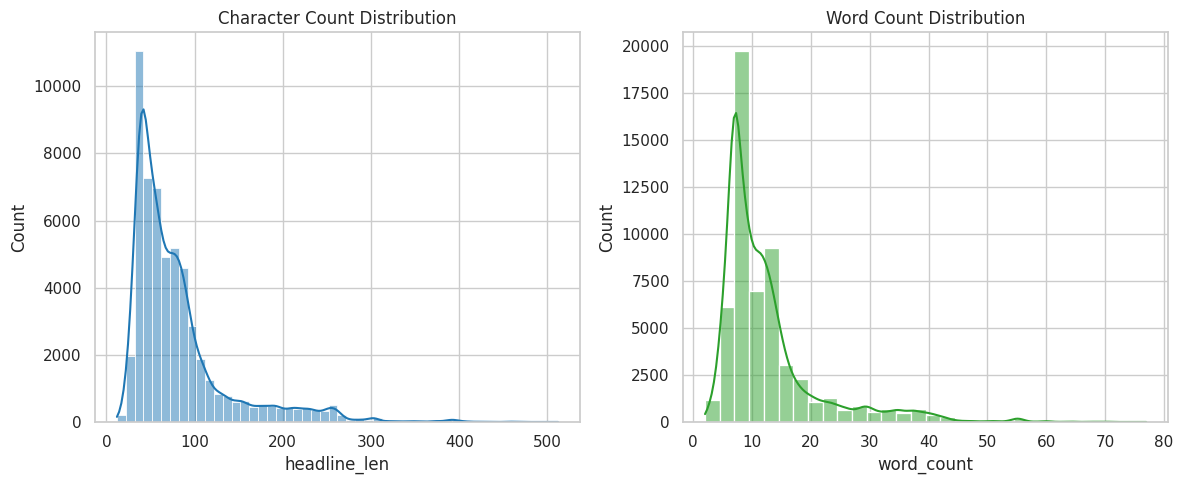

In [5]:
print("📏 Headline Statistics:")
print(df[['headline_len', 'word_count']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df, x='headline_len', bins=50, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Character Count Distribution')
sns.histplot(df, x='word_count', bins=30, kde=True, ax=axes[1], color='#2ca02c')
axes[1].set_title('Word Count Distribution')
plt.tight_layout()
plt.savefig('../reports/headline_length_dist.png', dpi=300, bbox_inches='tight')
plt.show()

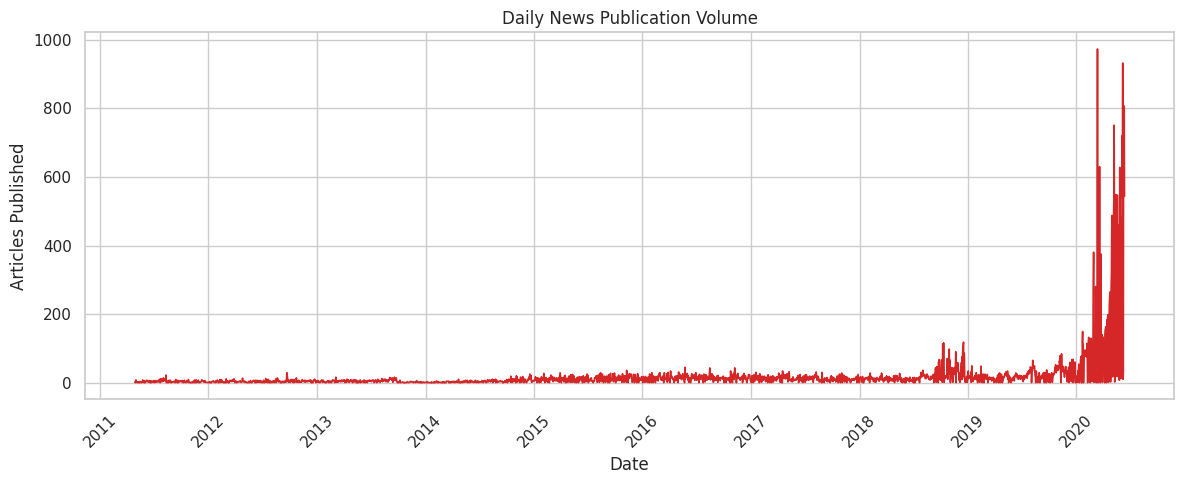

📈 Peak day: 2020-03-12 with 973 articles


In [6]:
df['trading_date'] = df['date_parsed'].dt.date
daily_vol = df.groupby('trading_date').size().reset_index(name='count')
daily_vol['trading_date'] = pd.to_datetime(daily_vol['trading_date'])

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_vol, x='trading_date', y='count', linewidth=1.2, color='#d62728')
plt.title('Daily News Publication Volume')
plt.xlabel('Date')
plt.ylabel('Articles Published')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/news_volume_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

peak_day = daily_vol.loc[daily_vol['count'].idxmax()]
print(f"📈 Peak day: {peak_day['trading_date'].date()} with {peak_day['count']} articles")

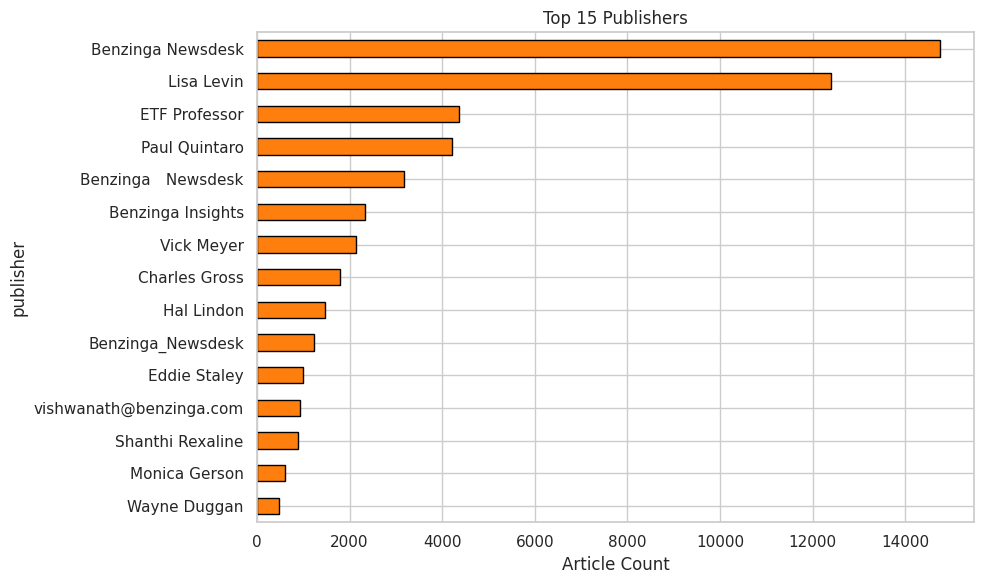

🌐 Top 10 Publisher Domains:
domain
unknown         54788
benzinga.com     1196
gmail.com           3
Name: count, dtype: int64


In [7]:
top_pub = df['publisher'].value_counts().head(15)
plt.figure(figsize=(10, 6))
top_pub.plot(kind='barh', color='#ff7f0e', edgecolor='black')
plt.title('Top 15 Publishers')
plt.xlabel('Article Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/top_publishers.png', dpi=300, bbox_inches='tight')
plt.show()

# Extract domains from emails (if applicable)
df['domain'] = df['publisher'].apply(lambda x: str(x).split('@')[-1] if '@' in str(x) else 'unknown')
top_domains = df['domain'].value_counts().head(10)
print("🌐 Top 10 Publisher Domains:")
print(top_domains)

🔑 Top 20 Keywords/Phrases:
          keyword       score
           stocks 6255.520913
           shares 4495.544586
           market 3911.392128
             week 3699.312205
              eps 3567.692306
               52 3366.776531
          52 week 3262.976975
          trading 3195.059218
            price 2920.236441
           target 2699.563327
     price target 2638.772998
            sales 2602.474039
              hit 2313.058759
        companies 2303.235469
       stocks hit 2268.579414
           hit 52 2268.074842
           higher 2237.751611
companies trading 1955.807830
         estimate 1884.608469
             lows 1614.303036


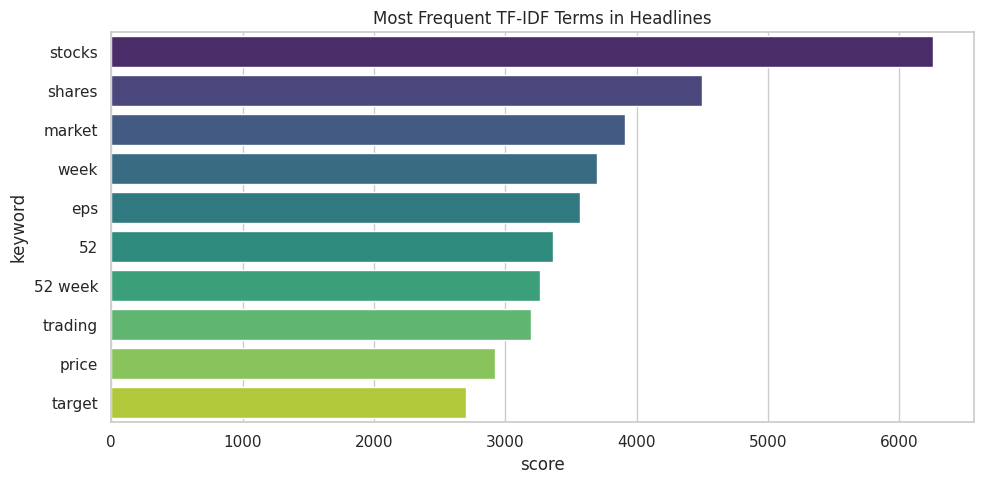

In [8]:
tfidf = TfidfVectorizer(max_features=20, stop_words='english', ngram_range=(1, 2))
tfidf_mat = tfidf.fit_transform(df['headline'])
scores = tfidf_mat.sum(axis=0).A1
keywords = pd.DataFrame({'keyword': tfidf.get_feature_names_out(), 'score': scores})
keywords = keywords.sort_values('score', ascending=False)

print("🔑 Top 20 Keywords/Phrases:")
print(keywords.head(20).to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=keywords.head(10), x='score', y='keyword', palette='viridis')
plt.title('Most Frequent TF-IDF Terms in Headlines')
plt.tight_layout()
plt.savefig('../reports/tfidf_keywords.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Save for Task 2 & 3
cols_to_keep = ['headline', 'url', 'publisher', 'date_parsed', 'stock', 'headline_len', 'word_count']
df[cols_to_keep].to_csv('../reports/news_cleaned.csv', index=False)
print("✅ Cleaned data saved to reports/news_cleaned.csv")

print("\n📋 INTERIM REPORT SNIPPET:")
print(f"• Total articles analyzed: {len(df):,}")
print(f"• Date range: {df['date_parsed'].min().date()} to {df['date_parsed'].max().date()}")
print(f"• Avg headline length: {df['headline_len'].mean():.1f} chars / {df['word_count'].mean():.1f} words")
print(f"• Top publisher: {top_pub.index[0]} ({top_pub.iloc[0]:,} articles)")
print(f"• Peak publishing day: {peak_day['trading_date'].date()}")

✅ Cleaned data saved to reports/news_cleaned.csv

📋 INTERIM REPORT SNIPPET:
• Total articles analyzed: 55,987
• Date range: 2011-04-28 to 2020-06-11
• Avg headline length: 80.0 chars / 12.4 words
• Top publisher: Benzinga Newsdesk (14,750 articles)
• Peak publishing day: 2020-03-12
